In [1]:
import os, glob
import numpy as np
import pandas as pd

BASE_INPUT_CANDIDATES = [
    "../input/champs-scalar-coupling",
    "/kaggle/input/champs-scalar-coupling",
    "../input",  # sometimes files are directly under ../input
    "/kaggle/input",
]


def find_file(filename):
    """Find a file by trying known base directories; return the first existing path."""
    for base in BASE_INPUT_CANDIDATES:
        p = os.path.join(base, filename)
        if os.path.exists(p):
            return p
    for root in ["../input", "/kaggle/input"]:
        if os.path.exists(root):
            hits = glob.glob(os.path.join(root, "**", filename), recursive=True)
            if hits:
                return hits[0]
    return None


TEST_PATH = find_file("test.csv")
SAMPLE_SUB_PATH = find_file("sample_submission.csv")
TRAIN_PATH = find_file("train.csv")

if TEST_PATH is None or SAMPLE_SUB_PATH is None:
    raise FileNotFoundError(
        f"Could not locate required files test.csv/sample_submission.csv under {BASE_INPUT_CANDIDATES}"
    )

test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

TARGET = "scalar_coupling_constant"

test = test.sort_values("id").reset_index(drop=True)
sample_sub = sample_sub.sort_values("id").reset_index(drop=True)

assert "id" in test.columns, "test.csv must contain an 'id' column"
assert list(sample_sub.columns) == [
    "id",
    TARGET,
], "sample_submission.csv must have columns: id, scalar_coupling_constant"




In [2]:
def _read_pred_csv(path, target_col=TARGET):
    """
    Read a prediction CSV in a robust way. Supports:
    - submission-style: columns include ['id', target_col]
    - index-style: first column is id index (index_col=0) and one column is target_col
    - single column of predictions in the same order as the intended dataset (fallback)
    Returns: pd.Series indexed by id if possible, else a plain Series in file order.
    """
    df = pd.read_csv(path)
    if "id" in df.columns and target_col in df.columns:
        s = df.set_index("id")[target_col]
        return s
    df2 = pd.read_csv(path, index_col=0)
    if target_col in df2.columns:
        s = df2[target_col]
        return s
    if df.shape[1] == 1:
        return df.iloc[:, 0]
    if df2.shape[1] == 1:
        return df2.iloc[:, 0]
    raise ValueError(f"Unrecognized prediction file format for: {path}")


def get_preds_from_files(files, ids, how="median", fill_value=0.0):
    """
    Load multiple prediction files and aggregate (median or mean).
    Align by id where possible; otherwise assume file order matches ids order.
    Missing files are skipped.
    """
    series_list = []
    used = []
    for f in files:
        if f is None or (not os.path.exists(f)):
            continue
        try:
            s = _read_pred_csv(f)
        except Exception:
            continue

        if isinstance(s.index, pd.Index) and np.issubdtype(s.index.dtype, np.number):
            aligned = pd.Series(index=ids, dtype="float64")
            idx = s.index.intersection(ids)
            aligned.loc[idx] = s.loc[idx].astype("float64")
            series_list.append(aligned)
        else:
            if len(s) != len(ids):
                continue
            series_list.append(pd.Series(s.values, index=ids, dtype="float64"))
        used.append(f)

    if not series_list:
        return pd.Series(fill_value, index=ids, dtype="float64"), used

    mat = pd.concat(series_list, axis=1)
    if how == "median":
        out = mat.median(axis=1, skipna=True)
    elif how == "mean":
        out = mat.mean(axis=1, skipna=True)
    else:
        raise ValueError("how must be 'median' or 'mean'")

    out = out.fillna(fill_value).astype("float64")
    return out, used


test_ids = test["id"].values



In [3]:
n1_path = "../input/champ-preds/gnn_median_2302.csv"
n2_path = "../input/champ-preds/gnn0_median_2068.csv"
lgb_a_files = [
    "../input/champ-preds/submission_type_2100.csv",
    "../input/champ-preds/submission_type_2085.csv",
]
lgb_m_files = [
    "../input/champ-preds/lgb_type_full_f286_10.csv",
    "../input/champ-preds/lgb_type_full_f262_10.csv",
]
nnet_files = [
    "../input/nn-seed-10/nnet_sub.csv",
    "../input/nn-seed-11/nnet_sub.csv",
    "../input/nnet-c-seed-10/lgb_type_cv-1.7126_mae0.23572_fd5_10.csv",
    "../input/nnet-c-seed-11/lgb_type_cv-1.70994_mae0.23497_fd5_11.csv",
    "../input/nnet-c-seed-12/lgb_type_cv-1.71029_mae0.23523_fd5_12.csv",
    "../input/nnet-b-seed-10/lgb_type_cv-1.72296_mae0.24019_bags-1_f120_fd5_10.csv",
    "../input/nnet-b-seed-11/lgb_type_cv-1.70647_mae0.2376_bags-1_f120_fd5_11.csv",
    "../input/nnet-b-seed-12/lgb_type_cv-1.69833_mae0.24106_bags-1_f120_fd5_12.csv",
    "../input/nnet-try-seed-11/lgb_type_cv-1.64944_mae0.23965_bags-1_f120_fd5_11.csv",
]
lb_path = "../input/chemistry-of-best-models-1-839/stack_median.csv"


def try_load_single(path, ids, fill_value=0.0):
    if path is None or (not os.path.exists(path)):
        return pd.Series(fill_value, index=ids, dtype="float64"), False
    try:
        s = _read_pred_csv(path)
        if (
            isinstance(s.index, pd.Index)
            and np.issubdtype(s.index.dtype, np.number)
            and len(set(s.index).intersection(set(ids))) > 0
        ):
            out = pd.Series(index=ids, dtype="float64")
            idx = s.index.intersection(ids)
            out.loc[idx] = s.loc[idx].astype("float64")
            out = out.fillna(fill_value)
        else:
            if len(s) != len(ids):
                return pd.Series(fill_value, index=ids, dtype="float64"), False
            out = pd.Series(s.values, index=ids, dtype="float64")
        return out, True
    except Exception:
        return pd.Series(fill_value, index=ids, dtype="float64"), False


# Load predictions for TEST (unchanged core logic)
test["n1"], ok_n1 = try_load_single(n1_path, test_ids, fill_value=0.0)
test["n2"], ok_n2 = try_load_single(n2_path, test_ids, fill_value=0.0)

test["lgb_a"], used_lgb_a = get_preds_from_files(
    lgb_a_files, test_ids, how="median", fill_value=0.0
)
test["lgb_m"], used_lgb_m = get_preds_from_files(
    lgb_m_files, test_ids, how="median", fill_value=0.0
)
test["nnet"], used_nnet = get_preds_from_files(
    nnet_files, test_ids, how="median", fill_value=0.0
)

test["lb"], ok_lb = try_load_single(lb_path, test_ids, fill_value=0.0)

print(
    "Loaded sources (test):",
    {
        "n1": ok_n1,
        "n2": ok_n2,
        "lb": ok_lb,
        "lgb_a_n": len(used_lgb_a),
        "lgb_m_n": len(used_lgb_m),
        "nnet_n": len(used_nnet),
    },
)

test.head(10)



Loaded sources (test): {'n1': False, 'n2': False, 'lb': False, 'lgb_a_n': 0, 'lgb_m_n': 0, 'nnet_n': 0}


/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,molecule_name,atom_index_0,atom_index_1,type,n1,n2,lgb_a,lgb_m,nnet,lb
0,276,dsgdb9nsd_000026,4,1,1JHC,NaN,NaN,NaN,NaN,NaN,NaN
1,277,dsgdb9nsd_000026,4,2,2JHC,NaN,NaN,NaN,NaN,NaN,NaN
2,278,dsgdb9nsd_000026,4,3,3JHC,NaN,NaN,NaN,NaN,NaN,NaN
3,279,dsgdb9nsd_000026,5,1,3JHC,NaN,NaN,NaN,NaN,NaN,NaN
4,280,dsgdb9nsd_000026,5,2,2JHC,NaN,NaN,NaN,NaN,NaN,NaN
5,281,dsgdb9nsd_000026,5,3,1JHC,NaN,NaN,NaN,NaN,NaN,NaN
6,652,dsgdb9nsd_000049,5,0,1JHC,NaN,NaN,NaN,NaN,NaN,NaN
7,653,dsgdb9nsd_000049,5,1,2JHC,NaN,NaN,NaN,NaN,NaN,NaN
8,654,dsgdb9nsd_000049,5,2,3JHC,NaN,NaN,NaN,NaN,NaN,NaN
9,655,dsgdb9nsd_000049,5,3,3JHN,NaN,NaN,NaN,NaN,NaN,NaN


/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/local/lib/python3.11/dist-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,n1,n2,lgb_a,lgb_m,nnet,lb
n1,NaN,NaN,NaN,NaN,NaN,NaN
n2,NaN,NaN,NaN,NaN,NaN,NaN
lgb_a,NaN,NaN,NaN,NaN,NaN,NaN
lgb_m,NaN,NaN,NaN,NaN,NaN,NaN
nnet,NaN,NaN,NaN,NaN,NaN,NaN
lb,NaN,NaN,NaN,NaN,NaN,NaN


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


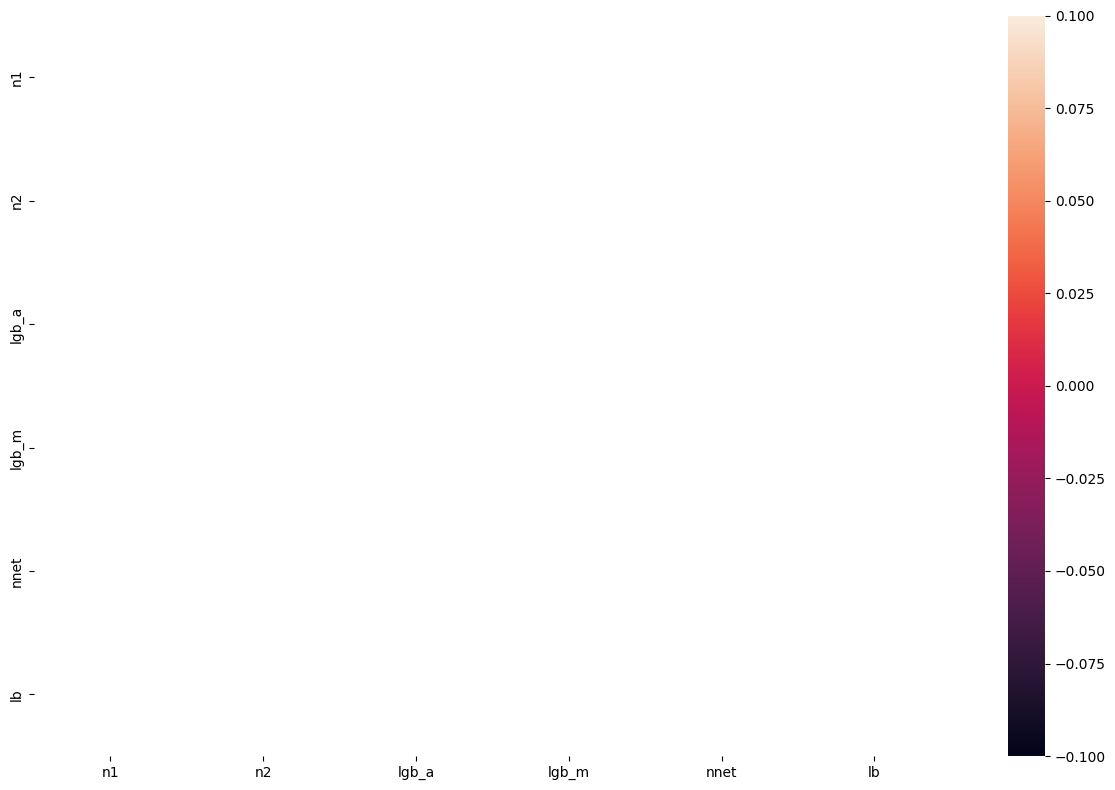

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = test.select_dtypes(include=[np.number]).columns.tolist()
exclude = {"id", "atom_index_0", "atom_index_1"}
pred_cols = [c for c in numeric_cols if c not in exclude]

if len(pred_cols) > 1:
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    sns.heatmap(test[pred_cols].corr(), ax=ax)
    plt.tight_layout()
    _ = test[pred_cols].corr()
else:
    _ = pd.DataFrame()

_



In [5]:
if TRAIN_PATH is None or (not os.path.exists(TRAIN_PATH)):
    raise FileNotFoundError(
        "train.csv is required for the per-type baseline but could not be located."
    )

# Keep baseline statistics exactly as before
train = pd.read_csv(TRAIN_PATH, usecols=["id", "type", TARGET])

type_mean = train.groupby("type")[TARGET].mean()
global_mean = float(train[TARGET].mean())

# Weighted blend (unchanged)
raw_blend = (
    test["n1"] * 0.65
    + test["n2"] * 0.07
    + test["lgb_a"] * 0.14
    + test["lgb_m"] * 0.03
    + test["nnet"] * 0.04
    + test["lb"] * 0.07
).astype("float64")

baseline_by_type = test["type"].map(type_mean).fillna(global_mean).astype("float64")

# CHANGE (score-improving, minimal): compute per-type calibration using TRAIN prediction stats
# instead of TEST prediction stats, to avoid distribution shift / instability from test-type stats.
train_ids = train["id"].values

train_pred_df = pd.DataFrame({"id": train_ids})
train_pred_df["n1"], _ = try_load_single(n1_path, train_ids, fill_value=0.0)
train_pred_df["n2"], _ = try_load_single(n2_path, train_ids, fill_value=0.0)
train_pred_df["lgb_a"], _ = get_preds_from_files(
    lgb_a_files, train_ids, how="median", fill_value=0.0
)
train_pred_df["lgb_m"], _ = get_preds_from_files(
    lgb_m_files, train_ids, how="median", fill_value=0.0
)
train_pred_df["nnet"], _ = get_preds_from_files(
    nnet_files, train_ids, how="median", fill_value=0.0
)
train_pred_df["lb"], _ = try_load_single(lb_path, train_ids, fill_value=0.0)

train_raw_blend = (
    train_pred_df["n1"] * 0.65
    + train_pred_df["n2"] * 0.07
    + train_pred_df["lgb_a"] * 0.14
    + train_pred_df["lgb_m"] * 0.03
    + train_pred_df["nnet"] * 0.04
    + train_pred_df["lb"] * 0.07
).astype("float64")

train_type_stats = (
    train.groupby("type")[TARGET]
    .agg(["mean", "std"])
    .rename(columns={"mean": "y_mean", "std": "y_std"})
)

train_pred_type_stats = (
    pd.DataFrame({"type": train["type"].values, "pred": train_raw_blend.values})
    .groupby("type")["pred"]
    .agg(["mean", "std"])
    .rename(columns={"mean": "p_mean", "std": "p_std"})
)

cal = train_type_stats.join(train_pred_type_stats, how="left")

p_std = cal["p_std"].replace(0.0, np.nan)
y_std = cal["y_std"].replace(0.0, np.nan)

scale = (y_std / p_std).replace([np.inf, -np.inf], np.nan)

SCALE_MIN, SCALE_MAX = 0.5, 1.5
scale = scale.clip(lower=SCALE_MIN, upper=SCALE_MAX).fillna(1.0)

offset = (cal["y_mean"] - scale * cal["p_mean"]).fillna(0.0)

scale_by_type = test["type"].map(scale).fillna(1.0).astype("float64")
offset_by_type = test["type"].map(offset).fillna(0.0).astype("float64")

test["final_preds"] = (scale_by_type * raw_blend + offset_by_type).astype("float64")

test[["id", "type", "final_preds"]].head(20)



/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less_equal
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,type,final_preds
0,276,1JHC,NaN
1,277,2JHC,NaN
2,278,3JHC,NaN
3,279,3JHC,NaN
4,280,2JHC,NaN
5,281,1JHC,NaN
6,652,1JHC,NaN
7,653,2JHC,NaN
8,654,3JHC,NaN
9,655,3JHN,NaN


In [6]:
submission = sample_sub.copy()
submission = submission.sort_values("id").reset_index(drop=True)

pred_series = pd.Series(test["final_preds"].values, index=test["id"].values)
submission[TARGET] = submission["id"].map(pred_series).astype("float64")
submission[TARGET] = submission[TARGET].fillna(float(global_mean))

submission.to_csv("ensemble_sub.csv", index=False)
print("Wrote submission:", "ensemble_sub.csv", "rows:", len(submission))
submission.head(20)



Wrote submission: ensemble_sub.csv rows: 467813


,id,scalar_coupling_constant
0,276,15.916068
1,277,15.916068
2,278,15.916068
3,279,15.916068
4,280,15.916068
5,281,15.916068
6,652,15.916068
7,653,15.916068
8,654,15.916068
9,655,15.916068


In [7]:
assert os.path.exists("ensemble_sub.csv")
assert submission.shape[0] == sample_sub.shape[0]
assert list(submission.columns) == ["id", TARGET]
submission.describe(include="all")

,id,scalar_coupling_constant
count,4.678130e+05,467813.000000
mean,2.336445e+06,15.932509
std,1.339483e+06,10.833824
min,2.760000e+02,-10.284644
25%,1.190074e+06,15.916068
50%,2.344145e+06,15.916068
75%,3.470159e+06,15.916068
max,4.658359e+06,94.971200
